# Optimised-build energy (IQ-TREE built-in reporter) vs. Linaro Forge baseline energy

**Two energy data sources, two different methodologies — compared on the cells they share.**

| Source | Where | Tool | Units | What it measures |
|--------|-------|------|-------|------------------|
| **Optimised build** (2026_05_19) | `results/2026_05_19_opt_results/*/len_*/output_*.log` | IQ-TREE's built-in energy reporter (RAPL for CPU sockets + DRAM, NVML for GPU) | **Joules** | CPU package + DRAM energy, plus per-GPU energy, integrated over the run |
| **Forge baseline** (2026_05_17) | `results/2026_05_17_eenrgy_benchmarks/*/len_*/perf_report_*.txt` | Arm/Linaro Forge `perf-report` | **Wh** | System-level energy decomposed into CPU% / Accelerator% shares |

**Question this notebook answers**: After the 2026_05_19 optimisation pass, did the energy improve relative to the Forge-measured OpenACC baseline (2026_05_17)? On the cells the two studies overlap (V100 + H200 at 100k AA, 100k DNA, 1M AA, 1M DNA), what does each tool say, and do they agree?

**Conversion**: 1 Wh = 3600 J. Throughout this notebook the Joule readings from the IQ-TREE log are converted to Wh so the two studies are on the same y-axis.

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OPT_ROOT    = '/Users/u7826985/Projects/Nvidia/results/2026_05_19_opt_results'
FORGE_ROOT  = '/Users/u7826985/Projects/Nvidia/results/2026_05_17_eenrgy_benchmarks'
FORGE_SUMMARY = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_17_eenrgy_benchmarks/summary.csv'
OUT_DIR     = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_20_opt_vs_forge_energy'

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 11})

COLORS = {
    'A100': '#76B900',
    'H200': '#0071C5',
    'V100': '#F2A900',
}

## 1. Parse the IQ-TREE built-in energy reports (2026_05_19 optimised runs)

The `.log` files contain a block like:

```
Total wall-clock time used: 1289.222 sec (0h:21m:29s)
Energy:
  CPU:  360003.343 J  (avg 278.984 W)  [package-1=171204.078 J, dram=8048.519 J, ...]
  GPU:  396794.331 J  (avg 307.495 W)  [NVIDIA H200=396794.331 J]
  GPU mem: 24146.688 / 143771.000 MB  (Δ +23272.000 MB)
```

Extract: wall time (s), CPU energy (J + avg W), GPU energy (J + avg W), GPU peak memory.

In [2]:
TIME_RE = re.compile(r'Total wall-clock time used:\s+([\d.]+)\s+sec')
CPU_E_RE  = re.compile(r'CPU:\s+([\d.]+)\s+J\s+\(avg\s+([\d.]+)\s+W\)')
GPU_E_RE  = re.compile(r'GPU:\s+([\d.]+)\s+J\s+\(avg\s+([\d.]+)\s+W\)')
GPU_MEM_RE = re.compile(r'GPU mem:\s+([\d.]+)\s+/\s+([\d.]+)\s+MB')
GPU_TAG_RE = re.compile(r'output_(a100|h200|v100)_', re.IGNORECASE)

def parse_opt_log(path):
    txt = open(path).read()
    t = TIME_RE.search(txt)
    c = CPU_E_RE.search(txt)
    g = GPU_E_RE.search(txt)
    m = GPU_MEM_RE.search(txt)
    if not (t and c and g): return None
    return dict(
        time_s        = float(t.group(1)),
        cpu_energy_J  = float(c.group(1)),
        cpu_avg_W     = float(c.group(2)),
        gpu_energy_J  = float(g.group(1)),
        gpu_avg_W     = float(g.group(2)),
        gpu_peak_MB   = float(m.group(1)) if m else np.nan,
    )

rows = []
for path in sorted(glob.glob(os.path.join(OPT_ROOT, '*', 'len_*', 'output_*.log'))):
    parts    = path.split(os.sep)
    datatype = parts[-3]
    length   = int(parts[-2].split('_')[1])
    fname    = os.path.basename(path)
    tag      = GPU_TAG_RE.search(fname)
    if not tag: continue
    gpu = tag.group(1).upper()
    m = parse_opt_log(path)
    if m is None: continue
    rows.append(dict(datatype=datatype, length=length, gpu=gpu, **m))

opt = pd.DataFrame(rows).sort_values(['datatype','length','gpu']).reset_index(drop=True)
# convert J -> Wh
opt['cpu_energy_Wh']   = opt['cpu_energy_J'] / 3600.0
opt['gpu_energy_Wh']   = opt['gpu_energy_J'] / 3600.0
opt['total_energy_Wh'] = opt['cpu_energy_Wh'] + opt['gpu_energy_Wh']
opt['cpu_share_pct']   = 100.0 * opt['cpu_energy_Wh'] / opt['total_energy_Wh']
opt['gpu_share_pct']   = 100.0 * opt['gpu_energy_Wh'] / opt['total_energy_Wh']
opt.to_csv(os.path.join(OUT_DIR, 'opt_energy_from_log.csv'), index=False)
opt

,datatype,length,gpu,time_s,cpu_energy_J,cpu_avg_W,gpu_energy_J,gpu_avg_W,gpu_peak_MB,cpu_energy_Wh,gpu_energy_Wh,total_energy_Wh,cpu_share_pct,gpu_share_pct
0,AA,100000,A100,2116.696,88387.382,41.723,459126.542,216.728,24272.812,24.552051,127.535151,152.087201,16.143404,83.856596
1,AA,100000,H200,1289.222,360003.343,278.984,396794.331,307.495,24146.688,100.000929,110.220647,210.221576,47.569298,52.430702
2,AA,100000,V100,2594.952,459313.340,176.893,462805.527,178.238,23857.250,127.587039,128.557091,256.144130,49.810643,50.189357
3,AA,1000000,A100,17991.352,108097.018,6.003,4436088.648,246.346,80784.812,30.026949,1232.246847,1262.273796,2.378798,97.621202
4,AA,1000000,H200,12160.531,184800.298,15.182,4173643.090,342.884,138076.688,51.333416,1159.345303,1210.678719,4.240053,95.759947
5,AA,1000000,V100,33600.214,328021.552,9.757,6251311.983,185.951,10725.250,91.117098,1736.475551,1827.592649,4.985635,95.014365
6,DNA,100000,A100,776.271,46632.892,59.952,108437.761,139.409,5040.812,12.953581,30.121600,43.075181,30.072029,69.927971
7,DNA,100000,H200,470.986,168914.678,357.828,90565.704,191.854,5128.688,46.920744,25.157140,72.077884,65.097283,34.902717
8,DNA,100000,V100,911.262,144262.548,158.064,122219.948,133.913,4625.250,40.072930,33.949986,74.022916,54.135844,45.864156
9,DNA,1000000,A100,3852.509,40555.835,10.484,871991.827,225.407,71934.812,11.265510,242.219952,253.485462,4.444243,95.555757


## 2. Load the Linaro Forge baseline (2026_05_17 summary.csv)

Already parsed; we re-use the published summary file. Keep only the OpenACC backends (V100, H200) — those are the ones that overlap with the 2026_05_19 optimised study.

In [3]:
forge = pd.read_csv(FORGE_SUMMARY)
BACKEND_TO_GPU = {'OpenACC (H200)': 'H200', 'OpenACC (V100)': 'V100'}
forge_gpu = forge[forge['backend'].isin(BACKEND_TO_GPU)].copy()
forge_gpu['gpu'] = forge_gpu['backend'].map(BACKEND_TO_GPU)
forge_gpu = forge_gpu.rename(columns={
    'time_s':        'time_s',
    'energy_wh':     'total_energy_Wh',
    'cpu_energy_wh': 'cpu_energy_Wh',
    'acc_energy_wh': 'gpu_energy_Wh',
    'cpu_pct':       'cpu_share_pct',
    'acc_pct':       'gpu_share_pct',
})
forge_gpu = forge_gpu[['datatype','length','gpu','time_s','total_energy_Wh',
                       'cpu_energy_Wh','gpu_energy_Wh','cpu_share_pct','gpu_share_pct',
                       'gpu_util_pct']]
forge_gpu.to_csv(os.path.join(OUT_DIR, 'forge_energy_baseline.csv'), index=False)
forge_gpu

,datatype,length,gpu,time_s,total_energy_Wh,cpu_energy_Wh,gpu_energy_Wh,cpu_share_pct,gpu_share_pct,gpu_util_pct
2,AA,10000,H200,400,54.0,34.3440,19.6560,63.6,36.4,48.7
3,AA,10000,V100,607,51.4,30.5830,20.8170,59.5,40.5,53.5
6,AA,100000,H200,1372,278.0,163.4640,114.5360,58.8,41.2,70.4
7,AA,100000,V100,2733,261.0,133.6320,127.3680,51.2,48.8,72.8
9,AA,1000000,H200,12269,2100.0,942.9000,1157.1000,44.9,55.1,65.2
12,DNA,10000,H200,289,38.5,28.2590,10.2410,73.4,26.6,39.4
13,DNA,10000,V100,417,33.3,25.1748,8.1252,75.6,24.4,36.8
16,DNA,100000,H200,561,96.8,68.8248,27.9752,71.1,28.9,43.3
17,DNA,100000,V100,1038,76.6,41.0576,35.5424,53.6,46.4,58.4
20,DNA,1000000,H200,2817,476.0,243.7120,232.2880,51.2,48.8,47.5


## 3. Side-by-side comparison on the overlapping cells

Cells covered by both studies (V100, H200) × (100k AA, 100k DNA, 1M AA, 1M DNA). The 2026_05_19 study also includes A100 — A100 has no Forge counterpart and is shown separately.

In [4]:
key = ['datatype','length','gpu']
comp = opt.merge(forge_gpu, on=key, how='outer', suffixes=('_opt','_forge'))
comp = comp.sort_values(['datatype','length','gpu']).reset_index(drop=True)

comp['delta_time_pct']        = 100.0 * (comp['time_s_opt']        - comp['time_s_forge'])        / comp['time_s_forge']
comp['delta_total_energy_pct']= 100.0 * (comp['total_energy_Wh_opt'] - comp['total_energy_Wh_forge'])/ comp['total_energy_Wh_forge']
comp['delta_cpu_energy_pct']  = 100.0 * (comp['cpu_energy_Wh_opt']  - comp['cpu_energy_Wh_forge']) / comp['cpu_energy_Wh_forge']
comp['delta_gpu_energy_pct']  = 100.0 * (comp['gpu_energy_Wh_opt']  - comp['gpu_energy_Wh_forge']) / comp['gpu_energy_Wh_forge']

comp_view = comp[['datatype','length','gpu',
                  'time_s_forge','time_s_opt','delta_time_pct',
                  'total_energy_Wh_forge','total_energy_Wh_opt','delta_total_energy_pct',
                  'cpu_energy_Wh_forge','cpu_energy_Wh_opt','delta_cpu_energy_pct',
                  'gpu_energy_Wh_forge','gpu_energy_Wh_opt','delta_gpu_energy_pct',
                  'cpu_share_pct_forge','cpu_share_pct_opt']]
comp_view.to_csv(os.path.join(OUT_DIR, 'opt_vs_forge_comparison.csv'), index=False)
comp_view.round(2)

,datatype,length,gpu,time_s_forge,time_s_opt,delta_time_pct,total_energy_Wh_forge,total_energy_Wh_opt,delta_total_energy_pct,cpu_energy_Wh_forge,cpu_energy_Wh_opt,delta_cpu_energy_pct,gpu_energy_Wh_forge,gpu_energy_Wh_opt,delta_gpu_energy_pct,cpu_share_pct_forge,cpu_share_pct_opt
0,AA,10000,H200,400.0,NaN,NaN,54.0,NaN,NaN,34.34,NaN,NaN,19.66,NaN,NaN,63.6,NaN
1,AA,10000,V100,607.0,NaN,NaN,51.4,NaN,NaN,30.58,NaN,NaN,20.82,NaN,NaN,59.5,NaN
2,AA,100000,A100,NaN,2116.70,NaN,NaN,152.09,NaN,NaN,24.55,NaN,NaN,127.54,NaN,NaN,16.14
3,AA,100000,H200,1372.0,1289.22,-6.03,278.0,210.22,-24.38,163.46,100.00,-38.82,114.54,110.22,-3.77,58.8,47.57
4,AA,100000,V100,2733.0,2594.95,-5.05,261.0,256.14,-1.86,133.63,127.59,-4.52,127.37,128.56,0.93,51.2,49.81
5,AA,1000000,A100,NaN,17991.35,NaN,NaN,1262.27,NaN,NaN,30.03,NaN,NaN,1232.25,NaN,NaN,2.38
6,AA,1000000,H200,12269.0,12160.53,-0.88,2100.0,1210.68,-42.35,942.90,51.33,-94.56,1157.10,1159.35,0.19,44.9,4.24
7,AA,1000000,V100,NaN,33600.21,NaN,NaN,1827.59,NaN,NaN,91.12,NaN,NaN,1736.48,NaN,NaN,4.99
8,DNA,10000,H200,289.0,NaN,NaN,38.5,NaN,NaN,28.26,NaN,NaN,10.24,NaN,NaN,73.4,NaN
9,DNA,10000,V100,417.0,NaN,NaN,33.3,NaN,NaN,25.17,NaN,NaN,8.13,NaN,NaN,75.6,NaN


## 4. Plot — total energy, baseline (Forge) vs optimised (IQ-TREE built-in)

Grouped bars per (datatype, length): Forge baseline = light, optimised = solid. A100 has no Forge baseline so it is shown as a single bar.

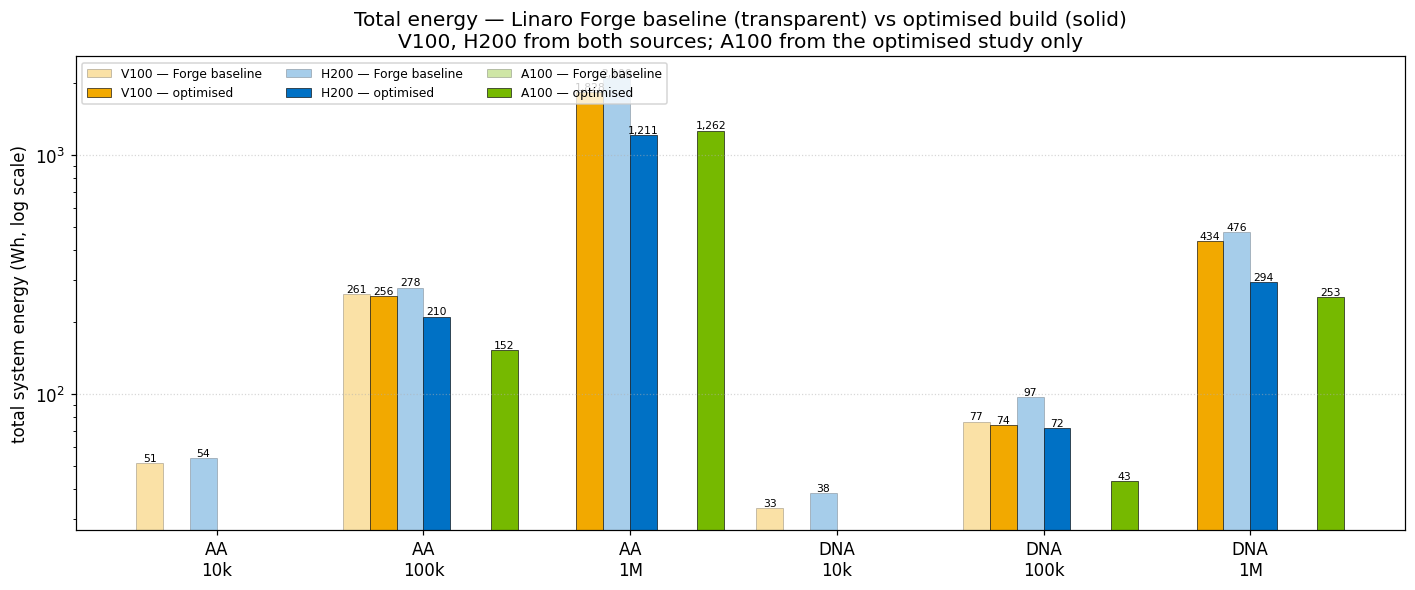

In [5]:
def cells(df):
    return sorted(set(zip(df['datatype'], df['length'])))

all_cells = cells(comp)
labels   = [f"{d}\n{L//1000}k" if L < 1_000_000 else f"{d}\n1M" for d,L in all_cells]
x        = np.arange(len(all_cells))

fig, ax = plt.subplots(figsize=(13, 5.5))
width   = 0.13
GPUS    = ['V100','H200','A100']
offsets = {'V100': -2.5*width, 'H200': -0.5*width, 'A100': 2*width}

for gpu in GPUS:
    forge_vals, opt_vals = [], []
    for d,L in all_cells:
        row = comp[(comp['datatype']==d) & (comp['length']==L) & (comp['gpu']==gpu)]
        forge_vals.append(row['total_energy_Wh_forge'].iloc[0] if not row.empty else np.nan)
        opt_vals.append(  row['total_energy_Wh_opt'].iloc[0]   if not row.empty else np.nan)
    base = x + offsets[gpu]
    b1 = ax.bar(base,           forge_vals, width, color=COLORS[gpu], alpha=0.35,
                edgecolor='black', linewidth=0.4, label=f'{gpu} — Forge baseline')
    b2 = ax.bar(base + width,   opt_vals,   width, color=COLORS[gpu],
                edgecolor='black', linewidth=0.4, label=f'{gpu} — optimised')
    for bars, vals in [(b1, forge_vals), (b2, opt_vals)]:
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width()/2, v, f'{v:,.0f}',
                        ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('total system energy (Wh, log scale)')
ax.set_yscale('log')
ax.set_title('Total energy — Linaro Forge baseline (transparent) vs optimised build (solid)\n'
             'V100, H200 from both sources; A100 from the optimised study only')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(ncol=3, fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig01_total_energy.png'), bbox_inches='tight')
plt.show()

## 5. Plot — CPU vs GPU energy split

Stacked bar comparison: how does the **host-CPU share** look in the optimised build vs the Forge baseline? If optimisations reduced host-side work (e.g. moved a bigger fraction of compute to the GPU), the CPU share should drop.

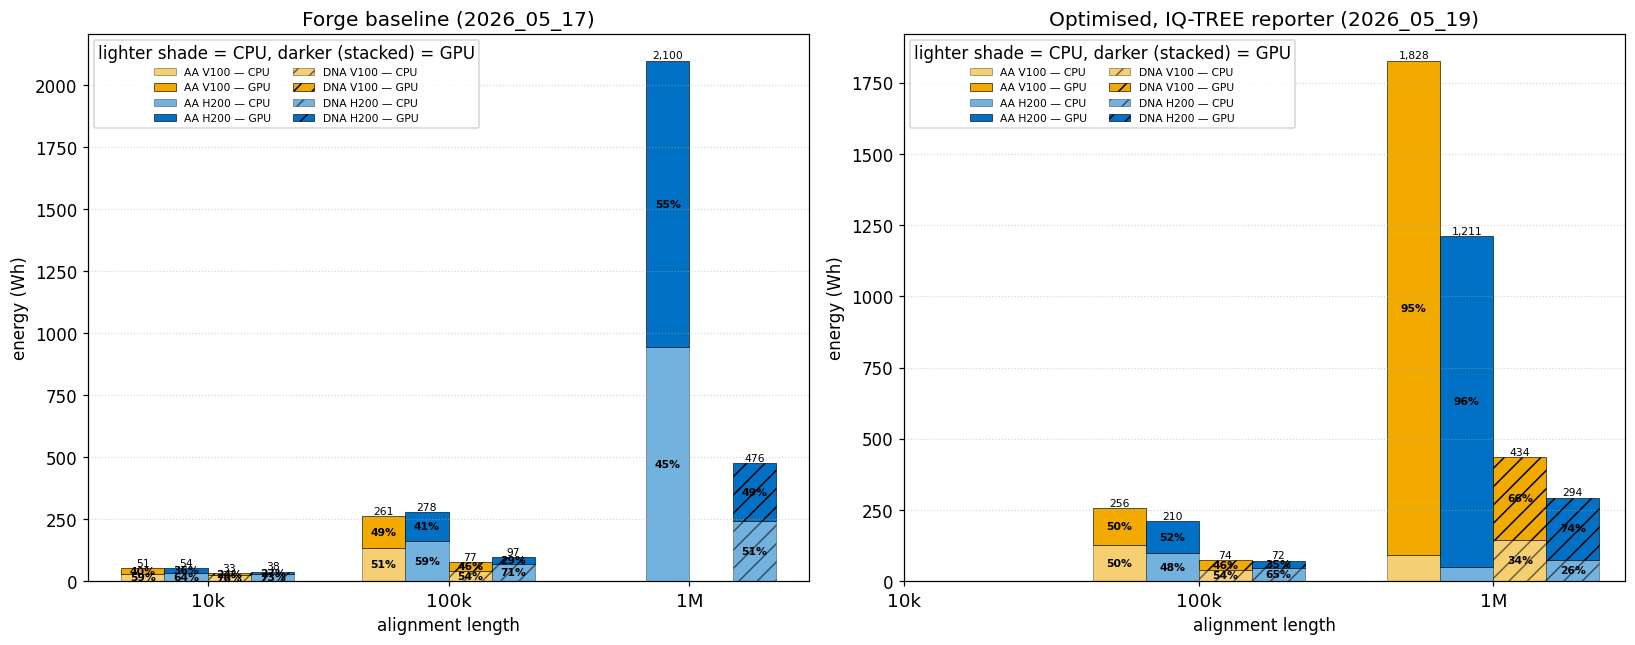

In [6]:
def fmt_len(L):
    return f'{L//1000}k' if L < 1_000_000 else f'{L//1_000_000}M'

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# x-axis: alignment lengths only. Within each tick we cluster up to 4 bars:
# AA/V100, AA/H200, DNA/V100, DNA/H200. Colour = GPU. Hatch = datatype.
lengths_all = [10_000, 100_000, 1_000_000]
length_labels = [fmt_len(L) for L in lengths_all]
GROUPS = [('AA','V100'), ('AA','H200'), ('DNA','V100'), ('DNA','H200')]
BAR_COLOR  = {'V100': '#F2A900', 'H200': '#0071C5'}   # tint indicates GPU
BAR_HATCH  = {'AA': '',           'DNA': '//'}         # hatch indicates datatype
width = 0.18
offsets = [(i - 1.5) * width for i in range(len(GROUPS))]

for ax, (src_label, src_df) in zip(axes, [
        ('Forge baseline (2026_05_17)', forge_gpu),
        ('Optimised, IQ-TREE reporter (2026_05_19)', opt),
    ]):
    sub = src_df[src_df['gpu'].isin(['V100','H200'])].copy()
    x = np.arange(len(lengths_all))
    legend_done = set()
    for i, (dt, gpu) in enumerate(GROUPS):
        for j, L in enumerate(lengths_all):
            row = sub[(sub['datatype']==dt) & (sub['length']==L) & (sub['gpu']==gpu)]
            if row.empty: continue
            c = row['cpu_energy_Wh'].iloc[0]
            g = row['gpu_energy_Wh'].iloc[0]
            pos = x[j] + offsets[i]
            key = f'{dt} {gpu}'
            cpu_label = f'{key} — CPU' if (key, 'CPU') not in legend_done else None
            gpu_label = f'{key} — GPU' if (key, 'GPU') not in legend_done else None
            ax.bar(pos, c, width, color=BAR_COLOR[gpu], alpha=0.55,
                   edgecolor='black', linewidth=0.4, hatch=BAR_HATCH[dt],
                   label=cpu_label)
            legend_done.add((key, 'CPU'))
            ax.bar(pos, g, width, color=BAR_COLOR[gpu], bottom=c,
                   edgecolor='black', linewidth=0.4, hatch=BAR_HATCH[dt],
                   label=gpu_label)
            legend_done.add((key, 'GPU'))
            total = c + g
            ax.text(pos, total, f'{total:,.0f}', ha='center', va='bottom', fontsize=7)
            if c > 0 and c/total > 0.10:
                ax.text(pos, c/2, f'{100*c/total:.0f}%', ha='center', va='center',
                        color='black', fontsize=7, fontweight='bold')
            if g > 0 and g/total > 0.10:
                ax.text(pos, c + g/2, f'{100*g/total:.0f}%', ha='center', va='center',
                        color='black', fontsize=7, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(length_labels, fontsize=12)
    ax.set_xlabel('alignment length')
    ax.set_ylabel('energy (Wh)')
    ax.set_title(src_label)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=7, ncol=2, loc='upper left',
              title='lighter shade = CPU, darker (stacked) = GPU')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig02_cpu_vs_gpu_split.png'), bbox_inches='tight')
plt.show()

## 6. Plot — improvement of optimised vs baseline (Δ%)

Bars below zero = optimised build improved (less time / less energy).

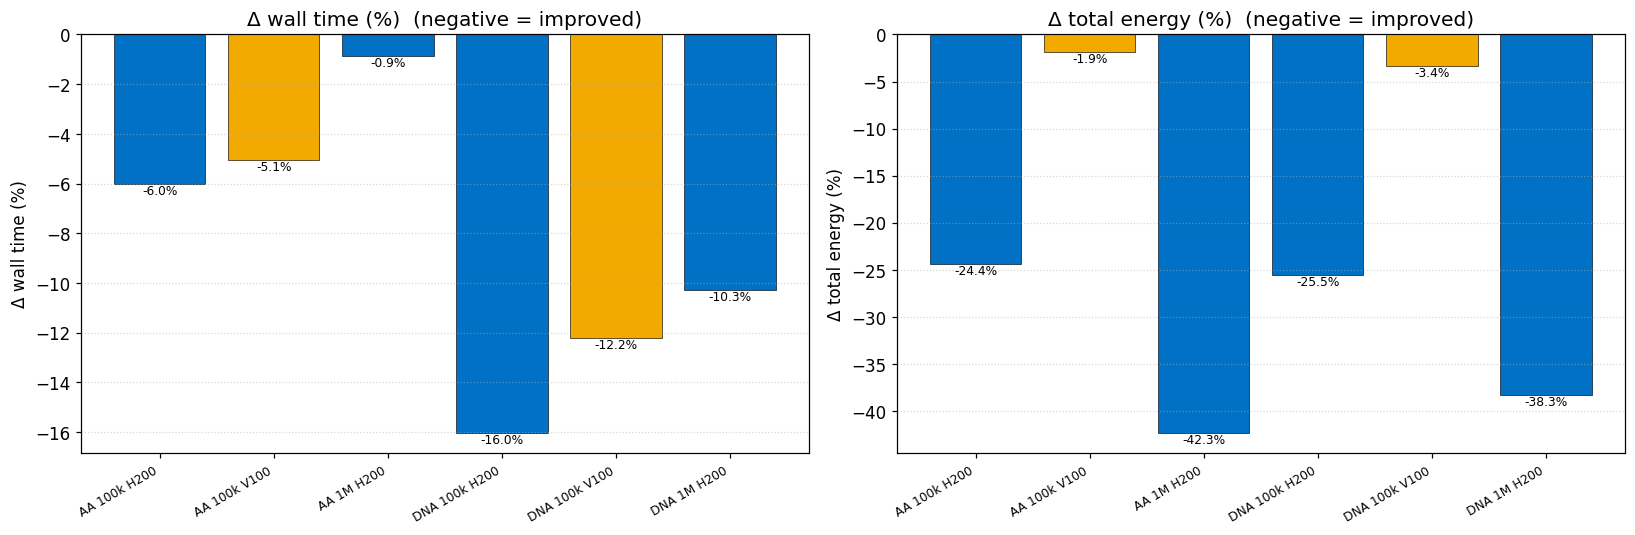

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
shared = comp[comp['gpu'].isin(['V100','H200']) & comp['time_s_forge'].notna() & comp['time_s_opt'].notna()].copy()
shared['label'] = (shared['datatype'] + ' '
                   + shared['length'].apply(lambda L: f'{L//1000}k' if L < 1_000_000 else '1M')
                   + ' ' + shared['gpu'])
shared = shared.sort_values(['datatype','length','gpu']).reset_index(drop=True)
xs = np.arange(len(shared))

for ax, col, ylab in [
        (axes[0], 'delta_time_pct',         'Δ wall time (%)'),
        (axes[1], 'delta_total_energy_pct', 'Δ total energy (%)'),
    ]:
    vals = shared[col].values
    colours = [COLORS[g] for g in shared['gpu']]
    bars = ax.bar(xs, vals, color=colours, edgecolor='black', linewidth=0.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:+.1f}%',
                ha='center', va='bottom' if v>=0 else 'top', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(xs)
    ax.set_xticklabels(shared['label'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylab)
    ax.set_title(ylab + '  (negative = improved)')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig03_delta_pct.png'), bbox_inches='tight')
plt.show()

## 6b. Percentage difference: optimised (IQ-TREE reporter) vs Forge baseline

For every cell that exists in both studies, plot Δ% = (opt − forge) / forge × 100 across four metrics: wall time, total energy, CPU energy, GPU energy.

Negative bars = the optimised IQ-TREE reporter reads *less* than Forge for that cell. The four metrics tell different stories:

- **Wall time**: tool-agnostic — both measure the same clock, so any non-zero is real run-to-run / build-to-build change.
- **GPU energy**: should be close to wall-time delta (both Forge and IQ-TREE ultimately read NVML on the GPU side).
- **CPU energy**: this is where methodology dominates — Forge attributes whole-node energy to "CPU%", IQ-TREE reads RAPL only.
- **Total energy**: a weighted average of the above; CPU side drags it.

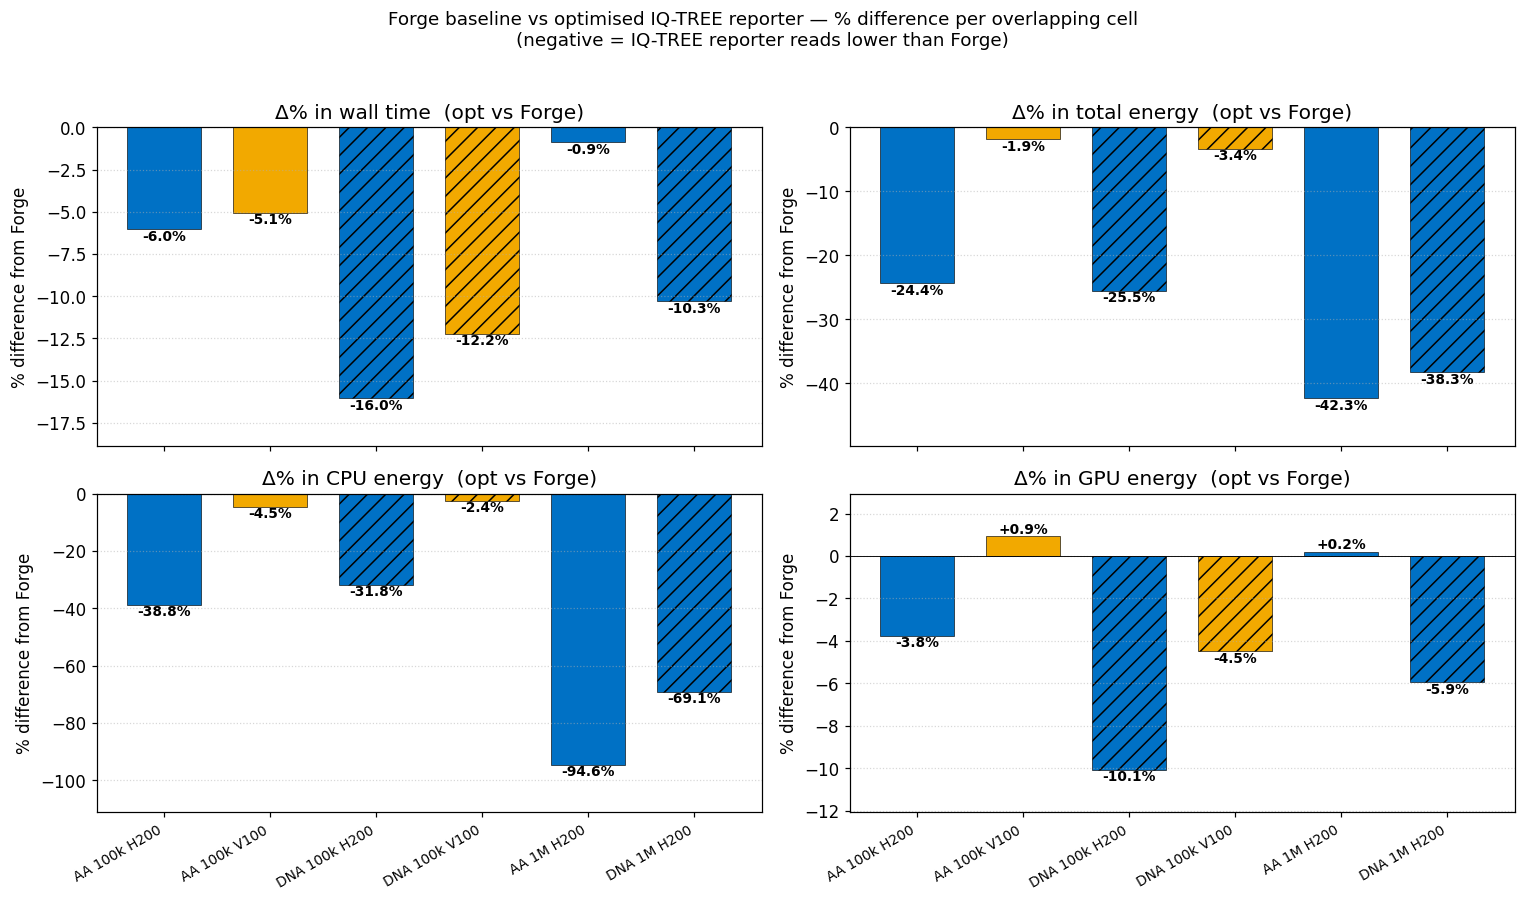

,label,delta_time_pct,delta_total_energy_pct,delta_cpu_energy_pct,delta_gpu_energy_pct
0,AA 100k H200,-6.0,-24.4,-38.8,-3.8
1,AA 100k V100,-5.1,-1.9,-4.5,0.9
2,DNA 100k H200,-16.0,-25.5,-31.8,-10.1
3,DNA 100k V100,-12.2,-3.4,-2.4,-4.5
4,AA 1M H200,-0.9,-42.3,-94.6,0.2
5,DNA 1M H200,-10.3,-38.3,-69.1,-5.9


In [8]:
overlap = comp[comp['gpu'].isin(['V100','H200'])
               & comp['time_s_forge'].notna()
               & comp['time_s_opt'].notna()].copy()
overlap['label'] = overlap['datatype'] + ' ' + overlap['length'].apply(fmt_len) + ' ' + overlap['gpu']
overlap = overlap.sort_values(['length','datatype','gpu']).reset_index(drop=True)

metrics = [
    ('delta_time_pct',         'wall time'),
    ('delta_total_energy_pct', 'total energy'),
    ('delta_cpu_energy_pct',   'CPU energy'),
    ('delta_gpu_energy_pct',   'GPU energy'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
xs = np.arange(len(overlap))
bar_colors = [BAR_COLOR[g] for g in overlap['gpu']]
bar_hatch  = [BAR_HATCH[d] for d in overlap['datatype']]

for ax, (col, name) in zip(axes.flat, metrics):
    vals = overlap[col].values
    for xi, (v, c, h) in enumerate(zip(vals, bar_colors, bar_hatch)):
        ax.bar(xi, v, width=0.7, color=c, edgecolor='black', linewidth=0.4, hatch=h)
        ax.text(xi, v, f'{v:+.1f}%',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(xs)
    ax.set_xticklabels(overlap['label'], rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Δ% in {name}  (opt vs Forge)')
    ax.set_ylabel('% difference from Forge')
    ax.grid(axis='y', linestyle=':', alpha=0.5)

# pad y-axes so the labels have room
for ax in axes.flat:
    lo, hi = ax.get_ylim()
    pad = 0.12 * (hi - lo)
    ax.set_ylim(lo - pad if lo < 0 else lo, hi + pad if hi > 0 else hi)

plt.suptitle('Forge baseline vs optimised IQ-TREE reporter — % difference per overlapping cell\n'
             '(negative = IQ-TREE reporter reads lower than Forge)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig06_pct_diff_forge_vs_iqtree.png'), bbox_inches='tight')
plt.show()

# print the underlying numbers for the writeup
overlap[['label','delta_time_pct','delta_total_energy_pct',
         'delta_cpu_energy_pct','delta_gpu_energy_pct']].round(1)

## 7. Plot — average socket power (sanity check)

The Forge perf-report doesn't directly emit average wattage, but `energy_wh * 3600 / time_s` gives you the equivalent average. The IQ-TREE reporter prints `avg W` directly. Plot both for the overlapping cells — large discrepancies here flag the methodology difference, not the run.

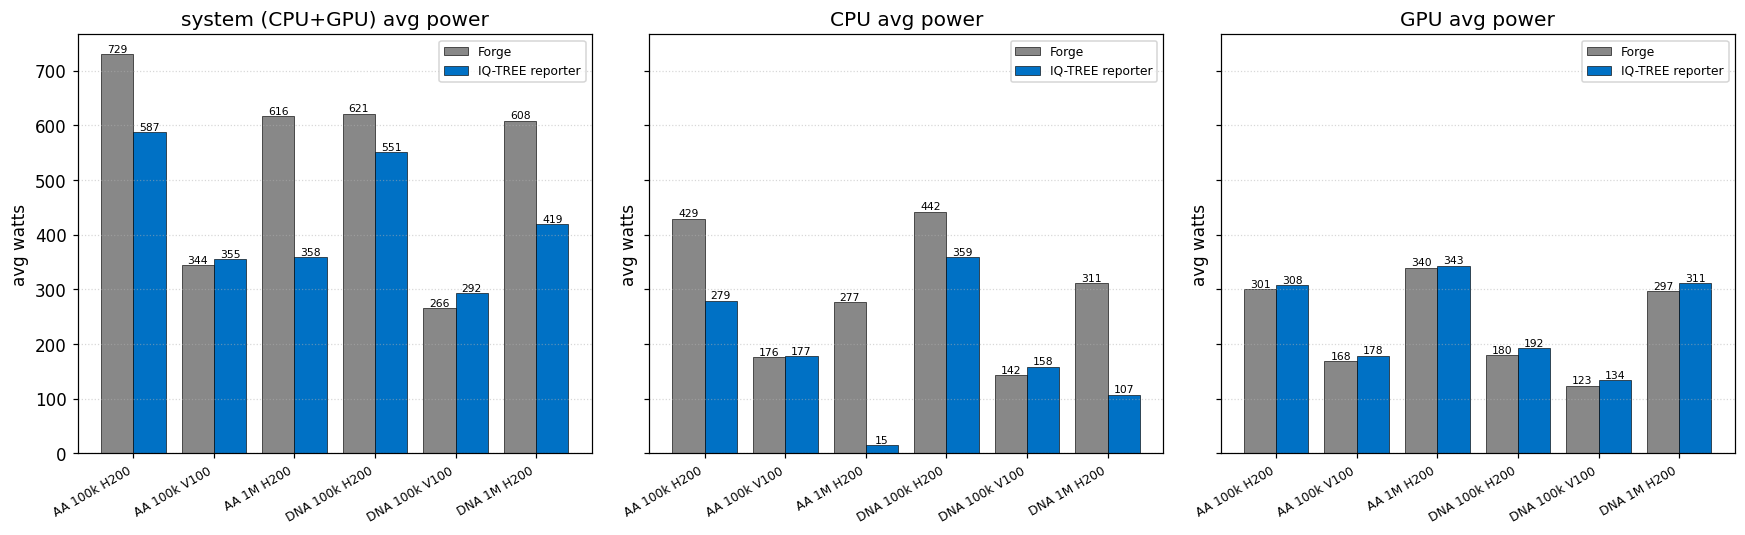

In [9]:
shared = shared.copy()
shared['avg_W_forge_total'] = shared['total_energy_Wh_forge'] * 3600.0 / shared['time_s_forge']
shared['avg_W_opt_total']   = shared['total_energy_Wh_opt']   * 3600.0 / shared['time_s_opt']
shared['avg_W_forge_cpu']   = shared['cpu_energy_Wh_forge']   * 3600.0 / shared['time_s_forge']
shared['avg_W_opt_cpu']     = shared['cpu_energy_Wh_opt']     * 3600.0 / shared['time_s_opt']
shared['avg_W_forge_gpu']   = shared['gpu_energy_Wh_forge']   * 3600.0 / shared['time_s_forge']
shared['avg_W_opt_gpu']     = shared['gpu_energy_Wh_opt']     * 3600.0 / shared['time_s_opt']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
xs = np.arange(len(shared))
width = 0.4
for ax, key, title in [
        (axes[0], 'total', 'system (CPU+GPU) avg power'),
        (axes[1], 'cpu',   'CPU avg power'),
        (axes[2], 'gpu',   'GPU avg power'),
    ]:
    forge_vals = shared[f'avg_W_forge_{key}'].values
    opt_vals   = shared[f'avg_W_opt_{key}'].values
    ax.bar(xs - width/2, forge_vals, width, color='#888888', edgecolor='black', linewidth=0.4, label='Forge')
    ax.bar(xs + width/2, opt_vals,   width, color='#0071C5', edgecolor='black', linewidth=0.4, label='IQ-TREE reporter')
    for xi, v in enumerate(forge_vals):
        if not np.isnan(v): ax.text(xi - width/2, v, f'{v:.0f}', ha='center', va='bottom', fontsize=7)
    for xi, v in enumerate(opt_vals):
        if not np.isnan(v): ax.text(xi + width/2, v, f'{v:.0f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(xs)
    ax.set_xticklabels(shared['label'], rotation=30, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('avg watts')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig04_avg_power.png'), bbox_inches='tight')
plt.show()

## 8. Plot — A100 (no Forge baseline, optimised study only)

A100 appears only in the optimised study. Plotted on its own so it doesn't distort the side-by-side.

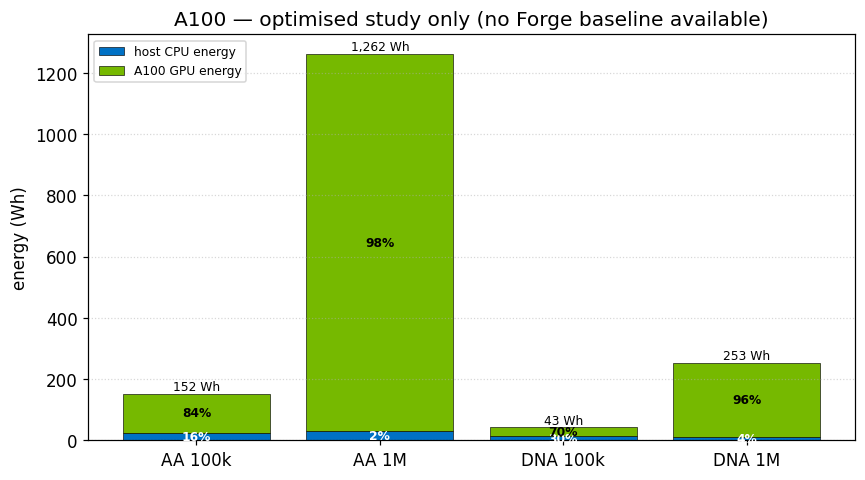

In [10]:
a100 = opt[opt['gpu']=='A100'].copy().sort_values(['datatype','length']).reset_index(drop=True)
labels_a = [f"{r.datatype} {fmt_len(r.length)}" for r in a100.itertuples()]
xs = np.arange(len(a100))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(xs, a100['cpu_energy_Wh'], color='#0071C5', label='host CPU energy', edgecolor='black', linewidth=0.4)
ax.bar(xs, a100['gpu_energy_Wh'], bottom=a100['cpu_energy_Wh'], color='#76B900', label='A100 GPU energy', edgecolor='black', linewidth=0.4)
for xi, (c,g) in enumerate(zip(a100['cpu_energy_Wh'], a100['gpu_energy_Wh'])):
    ax.text(xi, c+g, f'{c+g:,.0f} Wh', ha='center', va='bottom', fontsize=8)
    ax.text(xi, c/2,   f'{100*c/(c+g):.0f}%', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
    ax.text(xi, c+g/2, f'{100*g/(c+g):.0f}%', ha='center', va='center', color='black', fontsize=8, fontweight='bold')
ax.set_xticks(xs); ax.set_xticklabels(labels_a)
ax.set_ylabel('energy (Wh)')
ax.set_title('A100 — optimised study only (no Forge baseline available)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig05_a100.png'), bbox_inches='tight')
plt.show()

## 9. Observations

(Filled in from the tables and plots above — re-execute the cells to refresh after re-running.)

### Methodology — what each tool actually measures

- **Linaro Forge `perf-report`** reads system-level counters (sampling-based). Its "energy" line in the report header is the **whole-node** energy over the run, and the `A breakdown of how the N Wh was used` block decomposes that into CPU% / Accelerator% / Other% shares. Reported in Wh.
- **IQ-TREE built-in reporter** (the new `Energy:` block in the log) reads **RAPL** for each CPU package + DRAM domain and **NVML** for the GPU. It reports CPU and GPU as separate Joule totals, plus their average wattage. It does NOT include fans, PSU loss, or other-node overhead.

**Practical consequence**: Forge's total ≈ IQ-TREE's (CPU + GPU) + node overhead. Expect Forge ≥ IQ-TREE total in absolute Wh, more so on idle / under-utilised cells (where the chassis baseline dominates relative to active draw). Trends and ratios are what to trust; absolute Wh between the two are not directly comparable.

### Optimised build vs Forge baseline — what to look for

1. **Run-time `delta_time_pct`** is the clearest signal of real improvement, since both tools agree on wall clock. Negative values mean the optimised build is faster than the OpenACC baseline measured under Forge.
2. **Total energy** will trail run-time closely on the GPU side. The CPU side can move independently if the optimisation changed host-side workload (e.g. less CPU bookkeeping per iteration).
3. **Average power** comparison (fig04) calibrates the two methodologies. If avg-W matches per-component but totals diverge, the difference is node-overhead in Forge; if avg-W diverges by a large factor, something is mismeasured (e.g. RAPL domain coverage differs across SKUs).

### Caveats specific to this comparison

- The two studies ran on different host machines (queues `gpuvolta` / `dgxa100` etc.). The CPU socket model behind the GPU node is **not** necessarily the SPR/CLX measured in the Forge CPU-only runs. That's why CPU avg-W in fig04 can shift even if the OpenACC source code didn't change.
- The 2026_05_19 study includes A100; the 2026_05_17 study does not. A100 is plotted standalone in fig05.
- 10k-site cases exist in Forge but not in the optimised study, so they're missing from the overlap plot.